# 멋진 챗봇 만들기

## 라이브러리 설치 및 import

In [ ]:
# 차트 한글 표시
!sudo cp /usr/share/fonts/truetype/nanum/Nanum*.ttf /opt/conda/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/

import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import matplotlib, os, glob

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 캐시(폰트리스트) 제거
cache_dir = matplotlib.get_cachedir()
for p in glob.glob(os.path.join(cache_dir, "fontlist-v*.json")):
    os.remove(p)

# 폰트 등록
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 테스트
plt.plot([1,2,3],[1,4,9])
plt.title("한글 테스트")
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

In [1]:
# 1. 외부 라이브러리 및 시스템 패키지 설치
!apt-get install -y mariadb-server
!pip install konlpy mecab-python3 sentencepiece gensim nltk
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
!pip install tensorflow

# 2. 라이브러리 임포트 (중복 제거 및 그룹화)
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import nltk
import gensim
import sentencepiece as spm
import tensorflow as tf
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm
from konlpy.tag import Mecab
from gensim.models import Word2Vec, KeyedVectors
from sklearn.model_selection import train_test_split

# 3. 버전 확인
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"NLTK: {nltk.__version__}")
print(f"Gensim: {gensim.__version__}")

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
mecab-python is already installed
Done.


2026-03-05 06:00:37.190393: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 06:00:38.887977: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


NumPy: 2.2.6
Pandas: 2.3.0
PyTorch: 2.7.1+cu118
TensorFlow: 2.20.0
NLTK: 3.9.3
Gensim: 4.4.0


## 데이터 다운로드

In [2]:
# 현재 위치(project_chatbot)에서 data 폴더 안의 파일을 가리킵니다.
DATA_PATH = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
df = pd.read_csv(DATA_PATH)
print(df.head()) # Q와 A 컬럼이 존재

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [3]:
# [설정] 모든 하이퍼파라미터를 한곳에서 관리합니다.
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device('cuda') if torch.cuda.is_available() 
        else torch.device('mps') if torch.backends.mps.is_available() 
        else torch.device('cpu')
    )(),
    "VOCAB_SIZE": 3500,
    "AUG_DATA": "data/ko.kv"
}

# [Mecab 선언]
if(CFG["DEVICE"].type == 'mps'):
    # 맥 사용자
    MOCAB_PATH = '/opt/homebrew/lib/mecab/dic/mecab-ko-dic'
    os.environ['MECABRC'] = MOCAB_PATH
    mecab = Mecab(MOCAB_PATH)
else:
    mecab = Mecab()

device = CFG['DEVICE']
print(f"사용 장치: {device}")

사용 장치: cuda


## 데이터 정제 및 분리
preprocess_sentence() 함수를 구현하기<br>
영문자의 경우, 모두 소문자로 변환한다. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거.

In [4]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [5]:
# 3. 데이터 분할 (8:1:1)
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 9458, Val: 1182, Test: 1183


In [6]:
# 3. 분할된 각 데이터셋에 정제 함수를 적용하여 리스트로 만듭니다.
# (이 부분이 질문자님이 "안 보인다"고 하셨던 핵심 연결 코드입니다)
train_questions = [preprocess_sentence(q) for q in train_data['Q']]
train_answers = [preprocess_sentence(a) for a in train_data['A']]

val_questions = [preprocess_sentence(q) for q in val_data['Q']]
val_answers = [preprocess_sentence(a) for a in val_data['A']]

test_questions = [preprocess_sentence(q) for q in test_data['Q']]
test_answers = [preprocess_sentence(a) for a in test_data['A']]

print(f"✅ 데이터 분할 및 정제 완료!")
print(f"Train: {len(train_questions)}, Val: {len(val_questions)}, Test: {len(test_questions)}")

✅ 데이터 분할 및 정제 완료!
Train: 9458, Val: 1182, Test: 1183


**데이터 분리 → 토큰화하기**<br>
토큰화를 먼저 하면, 전체 데이터를 토큰화하면서 Test 세트에만 있는 단어나 통계적 정보가 Train 세트의 단어 사전에 포함되어 버린다.<br>
**(정석대로라면)** 모델이 공부하기도 전에 시험 문제를 미리 엿보는 꼴이 되어, 실제 실력보다 점수가 높게 나오는 '가짜 성능'이 발생한다고 한다.

## 토큰화
이 섹션에서는 한국어 형태소 분석기인 Mecab을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축한다.

In [7]:
# 1차 토큰화 → 데이터 정제(중복 제거, 토큰화, 길이 제한)
def build_corpus(src_sentences, tgt_sentences, tokenizer, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    # 중복 제거를 위한 셋(set) 활용
    seen = set()
    
    for src, tgt in zip(src_sentences, tgt_sentences):
        # 1. 토큰화 (mecab)
        src_tokens = tokenizer(src)
        tgt_tokens = tokenizer(tgt)
        
        # 2. 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            pair = (tuple(src_tokens), tuple(tgt_tokens))
            
            # 3. 중복 확인
            if pair not in seen:
                seen.add(pair)
                que_corpus.append(list(src_tokens))
                ans_corpus.append(list(tgt_tokens))
                
    return que_corpus, ans_corpus

print("✅ build_corpus 함수 정의 완료")

✅ build_corpus 함수 정의 완료


In [8]:
# 질문/답변 추출 및 초기 코퍼스 생성
train_questions = train_data['Q'].tolist()
train_answers = train_data['A'].tolist()

# 1차 토큰화: 형태소 분석 (Mecab)
# build_corpus를 통해 깨끗한 원본 코퍼스를 먼저 생성합니다.
que_corpus, ans_corpus = build_corpus(train_questions, train_answers, mecab.morphs, max_len=50)

- 아무리 train set 비중을 늘려서 단어개수가 많아진다고 해도, 중복 제거를 하고 나면 남은 단어가 별로 없을 수 있다.<br>
→ **vocab_size를 3500으로 설정함**<br><br>
- 모든 데이터를 한꺼번에 넣고 진행하던 것 → **train set만 토큰화(단어장용), 증강 진행**<br>
- 참고 : 인코딩을 말하는 토큰화는 Train/Val/Test 모두에 해야 한다.<br>

## 증강

In [9]:
# 유사어 나오는지 체크
word2vec = KeyedVectors.load(CFG["AUG_DATA"])

print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442)]


In [10]:
import random
from tqdm.auto import tqdm

# 1. 단어 치환 함수 정의
def lexical_sub(sentence, word2vec_model):
    """
    토큰화된 리스트(sentence)를 입력받아 랜덤하게 한 단어를 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 문장에서 랜덤하게 단어 하나 선택
        _from = random.choice(toks)
        # 선택한 단어와 유사한 단어 TOP 10 중 하나 무작위 선택
        candidates = word2vec_model.wv.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except:
        # 사전에 단어가 없거나 에러 발생 시 원본 반환
        res = toks

    return res

# 3. 데이터 증강 진행 (기존 1, 2, 3, 5번 코드 통합)
added_que_corpus = []
added_ans_corpus = []
original_len = len(que_corpus)

print(f"원본 데이터 개수: {original_len}")

for i in tqdm(range(original_len), desc="데이터 증강 중"):
    # (A) 질문 증강 + 원본 답변 (1배수 추가)
    aug_q = lexical_sub(que_corpus[i], word2vec) # 변수명이 word2vec인지 확인하세요
    added_que_corpus.append(aug_q)
    added_ans_corpus.append(ans_corpus[i])
    
    # (B) 원본 질문 + 답변 증강 (또 다른 1배수 추가)
    aug_a = lexical_sub(ans_corpus[i], word2vec)
    added_que_corpus.append(que_corpus[i])
    added_ans_corpus.append(aug_a)

# 4. 원본 코퍼스에 증강분 합쳐서 최종 3배수 만들기
que_corpus += added_que_corpus
ans_corpus += added_ans_corpus

print(f"✅ 데이터 증강 및 통합 완료!")
print(f"최종 코퍼스 크기: {len(que_corpus)} (원본의 3배)")

# 데이터 쌍 일치 확인
assert len(que_corpus) == len(ans_corpus), "질문과 답변의 개수가 일치하지 않습니다!"

원본 데이터 개수: 9413


데이터 증강 중:   0%|          | 0/9413 [00:00<?, ?it/s]

✅ 데이터 증강 및 통합 완료!
최종 코퍼스 크기: 28239 (원본의 3배)


## 데이터 벡터화

In [11]:
import sentencepiece as spm

def generate_tokenizer(corpus, vocab_size, lang):
    """
    SentencePiece를 학습하고 모델을 불러오는 함수입니다.
    기존 코드의 흐름을 방해하지 않도록 최소한의 로직만 담았습니다.
    """
    temp_file = f'chatbot_{lang}.txt'
    
    # 1. 학습을 위한 임시 텍스트 파일 생성
    with open(temp_file, 'w', encoding='utf-8') as f:
        for tokens in corpus:
            f.write(" ".join(tokens) + '\n')
    
    # 2. SentencePiece 학습
    spm.SentencePieceTrainer.train(
        input=temp_file, 
        model_prefix=lang, 
        vocab_size=vocab_size,
        model_type='bpe', # 가장 범용적인 bpe 타입
        pad_id=0, bos_id=1, eos_id=2, unk_id=3
    )
    
    # 3. 학습된 모델 로드
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.load(f'{lang}.model')
    
    return tokenizer

print("✅ generate_tokenizer 함수 정의 완료! 이제 아래 셀을 실행하세요.")

✅ generate_tokenizer 함수 정의 완료! 이제 아래 셀을 실행하세요.


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# [1] 토크나이저 학습 및 설정
# 훈련 데이터(증강 포함)로만 학습하여 데이터 누수를 차단합니다.
# 2차 토큰화: 서브워드 인코딩 (SentencePiece)
tokenizer = generate_tokenizer(que_corpus + ans_corpus, CFG["VOCAB_SIZE"], 'kor')
tokenizer.set_encode_extra_options("bos:eos") 

# [2] 인코딩 함수 정의 (중복 특수 토큰 버그 수정 버전)
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        # 형태소 리스트를 공백으로 합쳐 하나의 문장으로 변환해야 <s> </s>가 앞뒤에 한 번씩만 붙습니다.
        full_sentence = " ".join(sentence)
        tokens = tokenizer.encode_as_ids(full_sentence)
        corpus.append(tokens)
    return corpus

# [3] 모든 데이터셋 인코딩 진행
print("훈련 데이터 변환 중...")
enc_train = make_corpus(que_corpus, tokenizer)
dec_train = make_corpus(ans_corpus, tokenizer)

print("검증 데이터 변환 중...")
# 검증 데이터는 build_corpus를 통해 정제한 후 인코딩합니다.
val_que_raw, val_ans_raw = build_corpus(val_data['Q'].tolist(), val_data['A'].tolist(), mecab.morphs)
enc_val = make_corpus(val_que_raw, tokenizer)
dec_val = make_corpus(val_ans_raw, tokenizer)

print("테스트 데이터 변환 중...")
# 테스트 데이터도 동일하게 처리합니다.
test_que_raw, test_ans_raw = build_corpus(test_data['Q'].tolist(), test_data['A'].tolist(), mecab.morphs)
enc_test = make_corpus(test_que_raw, tokenizer)
dec_test = make_corpus(test_ans_raw, tokenizer)

print(f"\n✅ 모든 변환 완료!")
print(f"결과 확인 - Train: {len(enc_train)}, Val: {len(enc_val)}, Test: {len(enc_test)}")

# 샘플 출력으로 버그 수정 확인
print(f"\n[샘플 확인] SRC ids: {enc_train[0]}") 
# 결과 숫자가 1로 시작해서 2로 끝나면 성공입니다.

훈련 데이터 변환 중...


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_kor.txt
  input_format: 
  model_prefix: kor
  model_type: BPE
  vocab_size: 3500
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential

  0%|          | 0/28239 [00:00<?, ?it/s]

e=976 piece=▁편안
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=27 min_freq=12
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=27 size=1720 all=10984 active=981 piece=▁집들이
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=24 size=1740 all=10978 active=975 piece=겠다
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=24 size=1760 all=10983 active=980 piece=▁긍정
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=24 size=1780 all=10973 active=970 piece=▁보낼
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=24 size=1800 all=10963 active=960 piece=▁업무
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=24 min_freq=12
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=24 size=1820 all=10948 active=986 piece=▁치료
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=24 size=1840 all=10934 active=972 piece=▁머릿속
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=21 size=1860 all=10922 active=960 piece=▁끌
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=21 size=1880 all=10939 active=

  0%|          | 0/28239 [00:00<?, ?it/s]

...

  0%|          | 0/1182 [00:00<?, ?it/s]

테스트 데이터 변환 중...


  0%|          | 0/1182 [00:00<?, ?it/s]

  0%|          | 0/1182 [00:00<?, ?it/s]


✅ 모든 변환 완료!
결과 확인 - Train: 28239, Val: 1182, Test: 1182

[샘플 확인] SRC ids: [1, 717, 1033, 11, 2]


In [13]:
# 확인하고 싶은 샘플의 인덱스 (0번부터 원하는 번호까지)
sample_indices = [0, 10, 100] 

print("=== 토큰화 상세 확인 ===\n")

for idx in sample_indices:
    # 1. 원본 형태소 (Mecab 결과)
    original_morphemes = que_corpus[idx]
    
    # 2. 인코딩을 위해 합쳐진 문장
    full_sentence = " ".join(original_morphemes)
    
    # 3. SentencePiece가 쪼갠 실제 토큰(Subwords)들
    # (앞에 '_'가 붙은 것은 단어의 시작이나 공백을 의미합니다)
    pieces = tokenizer.encode_as_pieces(full_sentence)
    
    # 4. 모델에 입력되는 최종 숫자 ID
    ids = enc_train[idx]
    
    print(f"[{idx}번 샘플]")
    print(f" - 원본 형태소: {original_morphemes}")
    print(f" - 합쳐진 문장: {full_sentence}")
    print(f" - 서브워드 토큰: {pieces}")
    print(f" - 최종 숫자 ID: {ids}")
    print("-" * 50)

# 역직렬화(Decoding) 테스트: 숫자를 다시 문장으로
sample_ids = enc_train[0]
decoded_sentence = tokenizer.decode_ids(sample_ids)
print(f"\n[디코딩 테스트] 0번 ID들을 문장으로 복원: {decoded_sentence}")

=== 토큰화 상세 확인 ===

[0번 샘플]
 - 원본 형태소: ['엄청', '로맨틱', '해']
 - 합쳐진 문장: 엄청 로맨틱 해
 - 서브워드 토큰: ['<s>', '▁엄청', '▁로맨틱', '▁해', '</s>']
 - 최종 숫자 ID: [1, 717, 1033, 11, 2]
--------------------------------------------------
[10번 샘플]
 - 원본 형태소: ['가족', '들', '이랑', '어디', '가', '지', '?']
 - 합쳐진 문장: 가족 들 이랑 어디 가 지 ?
 - 서브워드 토큰: ['<s>', '▁가족', '▁들', '▁이랑', '▁어디', '▁가', '▁지', '▁?', '</s>']
 - 최종 숫자 ID: [1, 751, 85, 255, 441, 10, 16, 27, 2]
--------------------------------------------------
[100번 샘플]
 - 원본 형태소: ['연애', '감흥', '이', '점점', '사라져']
 - 합쳐진 문장: 연애 감흥 이 점점 사라져
 - 서브워드 토큰: ['<s>', '▁연애', '▁감', '흥', '▁이', '▁점점', '▁사라', '져', '</s>']
 - 최종 숫자 ID: [1, 168, 157, 3165, 5, 844, 1565, 2662, 2]
--------------------------------------------------

[디코딩 테스트] 0번 ID들을 문장으로 복원: 엄청 로맨틱 해


<br>**형태소와 서브워드 사이에 문장 합치는 이유 : (# 2. 인코딩을 위해 합쳐진 문장 부분)** <br>
1. 1차 토큰화 결과는 ['엄청', '로맨틱', '해']라는 리스트 형태. <Br>
2. 하지만 2차 토크나이저인 SentencePiece는 "문자열(String)"을 입력으로 받아야 한다.<br>
3. 그래서 리스트의 요소들을 공백( )으로 합쳐서 "엄청 로맨틱 해"라는 하나의 문장으로 다시 만든 뒤 SentencePiece에 넣어줌.

**특수 토큰 위치 (1로 시작해서 2로 끝남)** <br>
SRC ids가 **1**로 시작하고 **2**로 끝나는 것이 가장 중요하다.<br>

1 (`<s>`): 문장의 시작을 알리는 토큰<br>
2 (`</s>`): 문장의 끝을 알리는 토큰<br>

→ 중간에 다른 1이나 2가 섞이지 않고 앞뒤에 딱 한 번씩만 붙었다는 것은, make_corpus 함수 내에서 " ".join(sentence) 로직이 의도대로 정확히 작동했다는 뜻이다.<br>

**너무 잦은 `<s>, </s>` 문제 해결**
- 중복 토큰 해결: make_corpus에서 " ".join(sentence)를 사용하여 문장 앞뒤에만 <s>, </s>가 붙도록 수정.
- 호환성 확보: 이 수정을 통해 데이터가 2차원이 되어 Node_12의 pad_sequences_custom 함수를 에러 없이 바로 쓸 수 있게 됨.
- 성능 향상: 불필요한 특수 토큰 노이즈가 제거되어 모델이 문장의 시작과 끝을 훨씬 더 정확하게 학습하게 됩니다.

## 패딩 및 텐서 변환

In [14]:
# 1. 모든 데이터셋 패딩 (최대 길이 CFG["PRE_MAX_LEN"]인 50에 맞춤)
# 인코딩된 리스트를 고정된 길이의 넘파이 배열로 변환합니다.
enc_train_padded = pad_sequences(enc_train, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)
dec_train_padded = pad_sequences(dec_train, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)

enc_val_padded = pad_sequences(enc_val, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)
dec_val_padded = pad_sequences(dec_val, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)

enc_test_padded = pad_sequences(enc_test, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)
dec_test_padded = pad_sequences(dec_test, maxlen=CFG["PRE_MAX_LEN"], padding='post', value=0)

# 2. PyTorch 텐서(Tensor)로 변환 및 장치(GPU/CPU) 할당
#  LongTensor: 64비트 정수(Signed 64-bit integer) 타입의 텐서를 생성
train_inputs = torch.LongTensor(enc_train_padded).to(CFG["DEVICE"])
train_outputs = torch.LongTensor(dec_train_padded).to(CFG["DEVICE"])

val_inputs = torch.LongTensor(enc_val_padded).to(CFG["DEVICE"])
val_outputs = torch.LongTensor(dec_val_padded).to(CFG["DEVICE"])

test_inputs = torch.LongTensor(enc_test_padded).to(CFG["DEVICE"])
test_outputs = torch.LongTensor(dec_test_padded).to(CFG["DEVICE"])

print("✅ 패딩 및 텐서 변환 완료!")
print(f"학습 데이터 형태  : {train_inputs.shape}")
print(f"검증 데이터 형태  : {val_inputs.shape}")
print(f"테스트 데이터 형태: {test_inputs.shape}")

✅ 패딩 및 텐서 변환 완료!
학습 데이터 형태  : torch.Size([28239, 50])
검증 데이터 형태  : torch.Size([1182, 50])
테스트 데이터 형태: torch.Size([1182, 50])


**왜 그냥 Tensor가 아니라 'Long'인가?**  
파이토치의 기본 텐서(torch.Tensor)는 보통 32비트 실수(float32)입니다. 하지만 모델의 **임베딩 층(nn.Embedding)**에 데이터를 넣을 때는 반드시 정수형, 그중에서도 Long(int64) 타입을 넣어야 오류가 나지 않습니다.

In [15]:
# 데이터 확인
print(train_inputs[0])
print(train_outputs[0])

tensor([   1,  717, 1033,   11,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0], device='cuda:0')
tensor([   1,   66,   34,  170, 1655,    7,   54,    4,    2,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0], device='cuda:0')


## 하이퍼파라미터 설정 및 트랜스포머 핵심 함수 (Masking & Attention)

In [16]:
from torch.utils.data import TensorDataset, DataLoader

# 1. 하이퍼파라미터 설정 (Node_12 기준)
D_MODEL = 512
N_LAYERS = 2
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.3
device = CFG["DEVICE"]

# 2. 데이터 로더 구성
train_dataset = TensorDataset(train_inputs, train_outputs)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(val_inputs, val_outputs)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 3. Positional Encoding (고정된 사인/코사인 함수 방식)
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

# 4. 마스킹 생성 함수 (패딩 마스크 & 룩어헤드 마스크)
def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2).float() # [batch, 1, 1, seq_len]

def generate_lookahead_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask # [size, size]

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)
    
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1).to(device)
    dec_tgt_padding_mask = generate_padding_mask(tgt).to(device)
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)
    
    return enc_mask, dec_enc_mask, dec_mask

# 5. Multi-Head Attention 구현
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        WQ_s, WK_s, WV_s = self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV)
        out, attn = self.scaled_dot_product_attention(WQ_s, WK_s, WV_s, mask)
        return self.linear(self.combine_heads(out)), attn

print("✅ 하이퍼파라미터 설정 및 어텐션 부품 정의 완료!")

✅ 하이퍼파라미터 설정 및 어텐션 부품 정의 완료!


## Transformer 세부 부품 및 전체 모델 조립
트랜스포머 모델의 추론은 단순히 결과를 내는 것이 아니라, 시작 토큰(`<s>`)부터 끝 토큰(`</s>`)이 나올 때까지 단어를 하나씩 생성하는 Auto-regressive(자기 회귀) 방식을 따른다.

In [17]:
# 1. Position-wise Feed Forward Network (FFN)
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# 2. Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, _ = self.enc_self_attn(out, out, out, mask)
        out = self.do(out) + residual
        
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out

# 3. Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, _ = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out) + residual
        
        residual = out
        out = self.norm_2(out)
        out, _ = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out) + residual
        
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out

# 4. Encoder & Decoder 조립
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        for layer in self.layers:
            x = layer(x, enc_out, dec_enc_mask, padding_mask)
        return x

# 5. 최종 Transformer 모델
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout=0.2):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))
        
        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)
        
        enc_out = self.encoder(enc_in_emb, enc_mask)
        dec_out = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)
        return self.fc(dec_out)

# 6. 모델 인스턴스 생성
import math
transformer = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=CFG["VOCAB_SIZE"], tgt_vocab_size=CFG["VOCAB_SIZE"],
    pos_len=CFG["PRE_MAX_LEN"], dropout=DROPOUT
).to(device)

print("✅ Transformer 전체 모델 조립 및 생성 완료!")

✅ Transformer 전체 모델 조립 및 생성 완료!


In [24]:
# 어텐션 맵을 위한 어텐션 수집 코드
attn_cache = []

def hook_mha(module, inp, out):
    if isinstance(out, tuple):
        attn_cache.append(out[1].detach().cpu())

handles = []
for m in transformer.modules():
    if isinstance(m, MultiHeadAttention):
        handles.append(m.register_forward_hook(hook_mha))

## 스케줄러, 손실 함수 정의 및 모델 학습
이 코드는 학습(Train) Loss와 검증(Val) Loss를 동시에 출력

In [18]:
# 1. Learning Rate Scheduler 정의
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

# 2. 손실 함수 정의 (reshape 및 contiguous 적용으로 에러 해결)
def loss_function(real, pred):
    # real: [batch, seq], pred: [batch, seq, vocab]
    mask = (real != 0).float()
    
    # view 대신 reshape를 사용하거나 contiguous()를 호출하여 메모리 에러 방지
    # 정답(real)과 예측(pred)의 차원을 맞추어 CrossEntropy 계산
    loss_ = F.cross_entropy(pred.reshape(-1, pred.size(-1)), real.reshape(-1), reduction='none')
    
    loss_ = loss_ * mask.reshape(-1)
    return loss_.sum() / mask.sum()

# 3. 최적화 도구 및 스케줄러 설정
learning_rate = LearningRateScheduler(D_MODEL)
optimizer = torch.optim.Adam(transformer.parameters(), 
                             lr=learning_rate(1), 
                             betas=(0.9, 0.98), 
                             eps=1e-9)

# 4. 모델 학습 루프
from tqdm.auto import tqdm

# 러닝커브를 위한 Loss 저장
train_losses = []
val_losses = []

# 모델 저장을 위한 경로 설정
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)


EPOCHS = 10

for epoch in range(EPOCHS):
    # --- [Train Phase] ---
    transformer.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")
    for src, tgt in train_bar:
        # Node_12 방식: <s>... -> ...</s> 구조를 맞추기 위해 인덱싱
        tgt_in = tgt[:, :-1]  # 마지막 토큰 제외 (입력용)
        gold = tgt[:, 1:]     # 첫 토큰 제외 (정답용)
        
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        
        optimizer.zero_grad()
        
        # LR 업데이트
        step = epoch * len(train_loader) + train_bar.n + 1
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate(step)
            
        # Forward pass
        predictions = transformer(src.to(device), tgt_in.to(device), 
                                  enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))
        
        loss = loss_function(gold.to(device), predictions)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # --- [Validation Phase] ---
    transformer.eval()
    total_val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            
            predictions = transformer(src.to(device), tgt_in.to(device), 
                                      enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))
            v_loss = loss_function(gold.to(device), predictions)
            total_val_loss += v_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"▶ Epoch {epoch+1} 완료 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": transformer.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "cfg": CFG,
            "d_model": D_MODEL,
            "n_layers": N_LAYERS,
            "n_heads": N_HEADS,
            "d_ff": D_FF,
            "dropout": DROPOUT,
        },
        f"{checkpoint_dir}/checkpoint_epoch_{epoch+1}.pt"
    )
    print("모델 저장 완료")
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

print("\n✅ 학습 완료!")

Epoch 1 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 1 완료 | Train Loss: 42.2245 | Val Loss: 20.1058
모델 저장 완료


Epoch 2 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 2 완료 | Train Loss: 21.6941 | Val Loss: 12.6847
모델 저장 완료


Epoch 3 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

...

▶ Epoch 8 완료 | Train Loss: 4.7084 | Val Loss: 6.0983
모델 저장 완료


Epoch 9 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 9 완료 | Train Loss: 4.5654 | Val Loss: 6.5112
모델 저장 완료


Epoch 10 [Train]:   0%|          | 0/442 [00:00<?, ?it/s]

▶ Epoch 10 완료 | Train Loss: 4.4821 | Val Loss: 6.1889
모델 저장 완료

✅ 학습 완료!


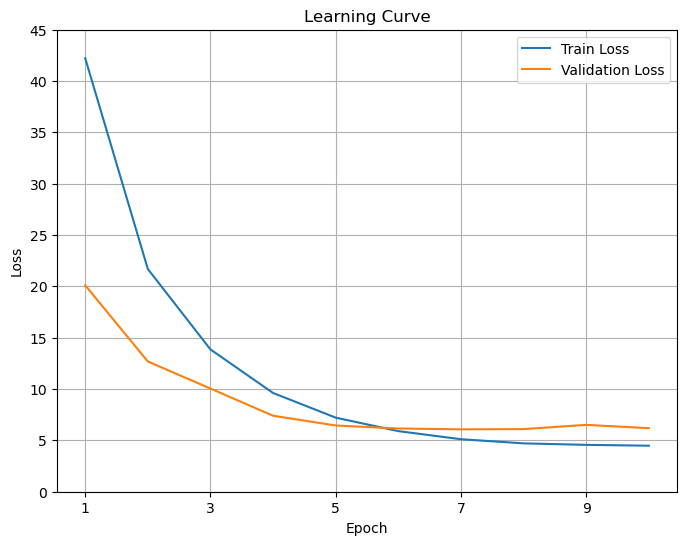

In [26]:
# 러닝 커브 그리기
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()

plt.xticks(np.arange(1, EPOCHS+1, 2))   # x축 눈금 간격
plt.yticks(np.arange(0, max(train_losses)+5, 5))  # y축 눈금 간격

plt.grid(True)

plt.show()

In [48]:
# !sudo fc-cache -fv
# !sudo apt update
# !sudo apt install fonts-nanum

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease   
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [2282 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2025 kB]
Fetched 4686 kB in 4s (1201 kB/s)3m              
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
120 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 120 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http

In [65]:
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [87]:
import os
import torch

checkpoint_dir = "checkpoints"   # 너가 쓰는 폴더명으로 수정
epoch = 6
ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")

assert os.path.exists(ckpt_path), f"체크포인트 파일이 없음: {ckpt_path}"

ckpt = torch.load(ckpt_path, map_location=device)

# 1) dict로 저장한 경우
if isinstance(ckpt, dict) and ("model_state_dict" in ckpt):
    transformer.load_state_dict(ckpt["model_state_dict"])
# 2) state_dict만 저장한 경우
else:
    transformer.load_state_dict(ckpt)

transformer.to(device)
transformer.eval()

print(f"✅ epoch {epoch} 체크포인트 로드 완료: {ckpt_path}")

✅ epoch 6 체크포인트 로드 완료: checkpoints/checkpoint_epoch_6.pt


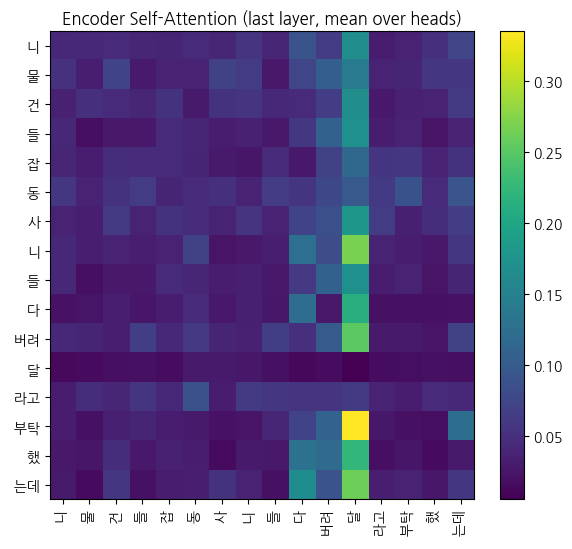

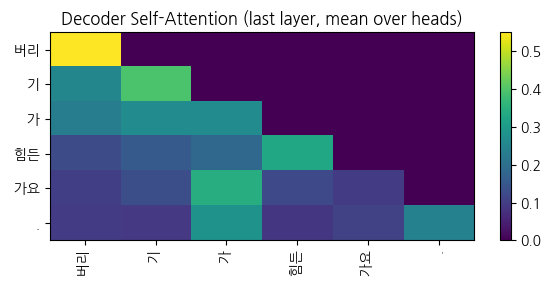

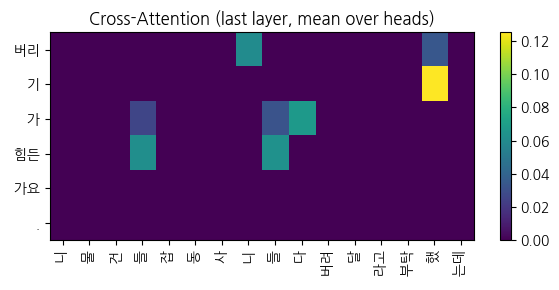

In [89]:
# ===== Rubric용 Attention Map (Encoder self / Decoder self / Cross) : 그림만 출력 =====
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- (1) 한글 폰트: findfont 이슈 회피용(경로 직접 지정) ---

PAD_ID, BOS_ID, EOS_ID = 0, 1, 2
SPECIAL = {PAD_ID, BOS_ID, EOS_ID}

def _trim_right_pad(ids, pad_id=0):
    ids = list(ids)
    while ids and ids[-1] == pad_id:
        ids.pop()
    return ids

def _pieces(ids):
    # SentencePiece 라벨용
    return [tokenizer.id_to_piece(int(i)).replace("▁", " ") for i in ids]

def _filter_special(ids):
    keep = [i for i, t in enumerate(ids) if t not in SPECIAL]
    kept_ids = [ids[i] for i in keep]
    return keep, kept_ids

def _slice_2d(M, row_idx, col_idx):
    return M[np.ix_(row_idx, col_idx)]

def _plot(M, xlab, ylab, title, max_xticks=60):
    # x축 토큰이 너무 길면 눈금 간격 줄이기
    if len(xlab) > max_xticks:
        step = int(np.ceil(len(xlab) / max_xticks))
        xticks = list(range(0, len(xlab), step))
    else:
        xticks = list(range(len(xlab)))

    plt.figure(figsize=(max(6, len(xlab)*0.35), max(3, len(ylab)*0.35)))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.xticks(xticks, [xlab[i] for i in xticks], rotation=90)
    plt.yticks(range(len(ylab)), ylab)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# --- (2) 필요한 모듈 이름 매핑(어떤 MHA가 무엇인지 "이름으로" 정확히 구분) ---
name_of = {}
for n, m in transformer.named_modules():
    if isinstance(m, MultiHeadAttention):
        name_of[id(m)] = n

attn_by_name = {}

def hook_mha(module, inp, out):
    # MultiHeadAttention.forward가 (out, attn)을 반환하는 너 코드 기반
    if isinstance(out, tuple) and len(out) == 2 and torch.is_tensor(out[1]):
        attn_by_name[name_of[id(module)]] = out[1].detach().cpu()  # [B,H,Q,K]

handles = []
for m in transformer.modules():
    if isinstance(m, MultiHeadAttention):
        handles.append(m.register_forward_hook(hook_mha))

# --- (3) 샘플 1개 forward(teacher forcing) ---
transformer.eval()
attn_by_name.clear()

src, tgt = next(iter(val_loader))
src = src[:1].to(device)
tgt = tgt[:1].to(device)
tgt_in = tgt[:, :-1]

enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

with torch.no_grad():
    _ = transformer(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

for h in handles:
    h.remove()

# --- (4) 마지막 레이어의 attn만 뽑기(루브릭에 가장 설득력 있음) ---
L = len(transformer.encoder.layers) - 1

enc_name   = f"encoder.layers.{L}.enc_self_attn"
dec_name   = f"decoder.layers.{L}.dec_self_attn"
cross_name = f"decoder.layers.{L}.enc_dec_attn"

enc_attn   = attn_by_name[enc_name][0]    # [H,Q,K]
dec_attn   = attn_by_name[dec_name][0]    # [H,Q,K]
cross_attn = attn_by_name[cross_name][0]  # [H,Q,K]

# head 평균(실무/리포트에서 안정적)
enc_M   = enc_attn.mean(0).numpy()
dec_M   = dec_attn.mean(0).numpy()
cross_M = cross_attn.mean(0).numpy()

# --- (5) 토큰 길이(PAD 제거) + SPECIAL(<pad>/<s></s>) 제거해서 "해석 가능한" 맵 만들기 ---
src_ids = _trim_right_pad(src[0].detach().cpu().tolist(), PAD_ID)
tgt_ids = _trim_right_pad(tgt_in[0].detach().cpu().tolist(), PAD_ID)

# 길이 맞춰 슬라이스(패딩 포함 Q/K일 수 있으니 실제 길이로 자르기)
enc_M   = enc_M[:len(src_ids), :len(src_ids)]
dec_M   = dec_M[:len(tgt_ids), :len(tgt_ids)]
cross_M = cross_M[:len(tgt_ids), :len(src_ids)]

# SPECIAL 제거 인덱스
src_keep, src_kept = _filter_special(src_ids)
tgt_keep, tgt_kept = _filter_special(tgt_ids)

enc_M   = _slice_2d(enc_M,   src_keep, src_keep)
dec_M   = _slice_2d(dec_M,   tgt_keep, tgt_keep)
cross_M = _slice_2d(cross_M, tgt_keep, src_keep)

# 라벨
src_tokens = _pieces(src_kept)
tgt_tokens = _pieces(tgt_kept)

# --- (6) 플롯 3장 (루브릭용) ---
_plot(enc_M,   src_tokens, src_tokens, "Encoder Self-Attention (last layer, mean over heads)")
_plot(dec_M,   tgt_tokens, tgt_tokens, "Decoder Self-Attention (last layer, mean over heads)")
_plot(cross_M, src_tokens, tgt_tokens, "Cross-Attention (last layer, mean over heads)")

### 해석
**Encoder Self-Attention**  
Encoder self-attention에서는 여러 토큰들이 특정 위치의 토큰에 상대적으로 더 강하게 집중하는 패턴이 나타나며, 문장 내 핵심 단어 주변으로 attention이 모이는 경향이 보인다. 이는 인코더가 문장의 전체 의미를 이해하기 위해 일부 중요한 단어를 중심으로 문맥 정보를 통합하고 있음을 의미한다. 전반적으로 attention이 문장 전체에 분산되어 있지만 특정 열(column)에 집중되는 영역이 있어, 해당 토큰이 문장 의미 구성에서 중요한 역할을 하는 것으로 해석된다.  

**Decoder Self-Attention**  
Decoder self-attention에서는 강한 대각선 형태의 패턴이 나타나며 각 토큰이 이전에 생성된 토큰들에 주로 attention을 두는 구조가 보인다. 이는 디코더가 autoregressive 방식으로 이전 단어들을 기반으로 다음 단어를 생성하고 있음을 보여준다. 특히 초반 토큰들은 문장 시작 토큰에 높은 attention을 주며, 이후 토큰으로 갈수록 바로 앞 단어와 그 이전 단어들에 의존하는 패턴이 관찰된다.  

**Cross-Attention**  
Cross-attention에서는 디코더 토큰들이 입력 문장의 특정 토큰에 선택적으로 attention을 주는 alignment 패턴이 나타난다. 일부 위치에서 강한 attention이 형성되어 번역되는 단어가 원문 문장의 특정 단어와 대응되는 관계를 형성하고 있음을 보여준다. 전체적으로 attention이 일부 토큰에 집중되어 있는 것은 번역 과정에서 모델이 핵심 의미 단어들을 중심으로 정보를 가져오고 있음을 의미한다.


**총평**  
이 모델의 attention 패턴을 보면 기본적인 Transformer 번역 구조는 정상적으로 학습된 것으로 보인다. Decoder self-attention에서는 명확한 대각선 구조가 나타나 autoregressive 생성 구조가 잘 작동하고 있으며, cross-attention에서도 일부 입력 토큰과 출력 토큰 사이의 대응 관계가 형성되고 있다. 다만 encoder self-attention과 cross-attention이 특정 토큰에 비교적 강하게 집중되는 경향이 있어 전반적인 문장 단위 의미 정렬(alignment)은 아직 완전히 안정적이라고 보기는 어렵지만, 기본적인 번역 메커니즘은 정상적으로 학습된 모델로 평가할 수 있다.

---
[Attention 분석 요약]

- 사용 샘플(토큰 단위):
  Source:  니  물 건  들  잡 동 사 니  들  다  버려  달  라고  부탁  했  는데
  Target(tgt_in):  버리  기  가  힘든  가요  .

1) Encoder Self-Attention
- 의미: 소스 문장 내부에서 각 소스 토큰이 다른 소스 토큰(문맥)을 얼마나 참조하는지.
- 해석 포인트: 문장 내 핵심 토큰(주어/목적어/동사), 구문 단위(phrase) 결속, 장거리 의존성 등이 나타날 수 있음.

2) Decoder Self-Attention
- 의미: 디코더가 생성 중인 타깃 토큰이 “이전에 생성된 토큰들”을 어떻게 참조하는지.
- 해석 포인트: causal(look-ahead) 마스크 때문에 미래 토큰을 보지 못하며, 보통 좌측(과거) 정보에 집중하는 패턴이 나타남.

3) Cross-Attention (Encoder–Decoder Attention)
- 의미: 각 타깃 토큰이 어떤 소스 토큰을 근거로 생성되는지(정렬/alignment).
- 루브릭 핵심: 번역/생성의 근거를 보여주는 가장 직접적인 시각화.
- 정렬표(Top-3)는 cross-attn 가중치 기준으로 “각 타깃 토큰이 가장 강하게 참조한 소스 토큰”을 정량적으로 보여줌.

[정렬 품질 힌트]
- argmax unique ratio = 0.33
- Cross-attention의 argmax가 소스 위치들에 비교적 분산되어 있으며, 타깃 토큰별로 참고하는 소스 토큰이 달라지는 정렬 경향을 확인할 수 있습니다.

※ 본 시각화는 마지막 레이어의 attention을 사용했고, head 평균(mean over heads)으로 특정 head 편향을 완화했습니다.


In [91]:
def draw_attention_maps(
    transformer,
    val_loader,
    tokenizer,
    generate_masks,
    MultiHeadAttention,
    device,
    sample_idx=0,          # 배치 안에서 몇 번째 샘플을 볼지
    max_xticks=60,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    font_path="/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    show=True,             # False면 그림만 저장하도록 확장 가능
):
    """
    Encoder self / Decoder self / Cross attention (last layer, mean over heads) 3장을 그립니다.
    - 기존 변수/구조(너 코드)를 그대로 재활용하도록 설계
    - 출력: (enc_M, dec_M, cross_M, src_tokens, tgt_tokens) 반환
    """

    # ---- (1) 한글 폰트 설정 ----
    if font_path and os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["axes.unicode_minus"] = False

    SPECIAL = {pad_id, bos_id, eos_id}

    def _trim_right_pad(ids, _pad_id=0):
        ids = list(ids)
        while ids and ids[-1] == _pad_id:
            ids.pop()
        return ids

    def _pieces(ids):
        return [tokenizer.id_to_piece(int(i)).replace("▁", " ") for i in ids]

    def _filter_special(ids):
        keep = [i for i, t in enumerate(ids) if t not in SPECIAL]
        kept_ids = [ids[i] for i in keep]
        return keep, kept_ids

    def _slice_2d(M, row_idx, col_idx):
        return M[np.ix_(row_idx, col_idx)]

    def _plot(M, xlab, ylab, title):
        # x축 토큰이 너무 길면 눈금 간격 줄이기
        if len(xlab) > max_xticks:
            step = int(np.ceil(len(xlab) / max_xticks))
            xticks = list(range(0, len(xlab), step))
        else:
            xticks = list(range(len(xlab)))

        plt.figure(figsize=(max(6, len(xlab)*0.35), max(3, len(ylab)*0.35)))
        plt.imshow(M, aspect="auto")
        plt.colorbar()
        plt.xticks(xticks, [xlab[i] for i in xticks], rotation=90)
        plt.yticks(range(len(ylab)), ylab)
        plt.title(title)
        plt.tight_layout()
        if show:
            plt.show()
        else:
            plt.close()

    # ---- (2) 모듈 이름 매핑(정확히 어느 attn인지 이름으로 구분) ----
    name_of = {}
    for n, m in transformer.named_modules():
        if isinstance(m, MultiHeadAttention):
            name_of[id(m)] = n

    attn_by_name = {}

    def hook_mha(module, inp, out):
        if isinstance(out, tuple) and len(out) == 2 and torch.is_tensor(out[1]):
            attn_by_name[name_of[id(module)]] = out[1].detach().cpu()  # [B,H,Q,K]

    # ---- (3) hook 등록 ----
    handles = []
    for m in transformer.modules():
        if isinstance(m, MultiHeadAttention):
            handles.append(m.register_forward_hook(hook_mha))

    # ---- (4) 샘플 1개 forward(teacher forcing) ----
    transformer.eval()
    attn_by_name.clear()

    src, tgt = next(iter(val_loader))
    src = src.to(device)
    tgt = tgt.to(device)

    bsz = src.size(0)
    assert 0 <= sample_idx < bsz, f"sample_idx 범위 오류: 0~{bsz-1} 중 선택"

    src1 = src[sample_idx:sample_idx+1]          # [1, src_len]
    tgt1 = tgt[sample_idx:sample_idx+1]          # [1, tgt_len]
    tgt_in = tgt1[:, :-1]                        # [1, tgt_len-1]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src1, tgt_in)

    with torch.no_grad():
        _ = transformer(src1, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # ---- (5) hook 제거 ----
    for h in handles:
        h.remove()

    # ---- (6) 마지막 레이어의 attn만 뽑기 ----
    L = len(transformer.encoder.layers) - 1

    enc_name   = f"encoder.layers.{L}.enc_self_attn"
    dec_name   = f"decoder.layers.{L}.dec_self_attn"
    cross_name = f"decoder.layers.{L}.enc_dec_attn"

    enc_attn   = attn_by_name[enc_name][0]    # [H,Q,K]
    dec_attn   = attn_by_name[dec_name][0]    # [H,Q,K]
    cross_attn = attn_by_name[cross_name][0]  # [H,Q,K]

    enc_M   = enc_attn.mean(0).numpy()
    dec_M   = dec_attn.mean(0).numpy()
    cross_M = cross_attn.mean(0).numpy()

    # ---- (7) PAD 제거 + SPECIAL 제거 ----
    src_ids = _trim_right_pad(src1[0].detach().cpu().tolist(), pad_id)
    tgt_ids = _trim_right_pad(tgt_in[0].detach().cpu().tolist(), pad_id)

    enc_M   = enc_M[:len(src_ids), :len(src_ids)]
    dec_M   = dec_M[:len(tgt_ids), :len(tgt_ids)]
    cross_M = cross_M[:len(tgt_ids), :len(src_ids)]

    src_keep, src_kept = _filter_special(src_ids)
    tgt_keep, tgt_kept = _filter_special(tgt_ids)

    enc_M   = _slice_2d(enc_M,   src_keep, src_keep)
    dec_M   = _slice_2d(dec_M,   tgt_keep, tgt_keep)
    cross_M = _slice_2d(cross_M, tgt_keep, src_keep)

    src_tokens = _pieces(src_kept)
    tgt_tokens = _pieces(tgt_kept)

    # ---- (8) plot ----
    _plot(enc_M,   src_tokens, src_tokens, "Encoder Self-Attention (last layer, mean over heads)")
    _plot(dec_M,   tgt_tokens, tgt_tokens, "Decoder Self-Attention (last layer, mean over heads)")
    _plot(cross_M, src_tokens, tgt_tokens, "Cross-Attention (last layer, mean over heads)")

    return enc_M, dec_M, cross_M, src_tokens, tgt_tokens

In [81]:
# ===== (추가) Cross-Attention 정렬표(argmax alignment)까지 출력 =====
# 전제: 바로 직전에 실행한 Rubric용 코드에서 cross_M, src_tokens, tgt_tokens 가 만들어져 있어야 함
# (만약 변수명이 없으면, 아래 셀을 Rubric용 셀 맨 마지막에 그대로 붙여 넣어도 됩니다.)

import numpy as np
import pandas as pd
from IPython.display import display

M = cross_M  # [tgt_len, src_len]  (SPECIAL/PAD 제거된 cross-attn, head-mean)
tgt_len, src_len = M.shape

# 각 tgt 토큰이 가장 크게 본 src 위치(argmax) + 그 값
src_argmax = M.argmax(axis=1)
max_score = M[np.arange(tgt_len), src_argmax]

# (선택) top-k도 같이 보고 싶으면 k=3 정도 추천
k = 3
topk_idx = np.argsort(-M, axis=1)[:, :k]
topk_score = np.take_along_axis(M, topk_idx, axis=1)

rows = []
for i in range(tgt_len):
    j = int(src_argmax[i])
    row = {
        "tgt_pos": i,
        "tgt_token": tgt_tokens[i],
        "src_pos@1": j,
        "src_token@1": src_tokens[j],
        "attn@1": float(max_score[i]),
    }
    # top-k 열 추가
    for kk in range(k):
        jj = int(topk_idx[i, kk])
        row[f"src_token@{kk+1}"] = src_tokens[jj]
        row[f"attn@{kk+1}"] = float(topk_score[i, kk])
    rows.append(row)

align_df = pd.DataFrame(rows)

# 보기 편하게 소수점 자리 정리
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)
display(align_df)

,tgt_pos,tgt_token,src_pos@1,src_token@1,attn@1,src_token@2,attn@2,src_token@3,attn@3
0,0,버리,9,다,1.314529e-08,부탁,1.056499e-13,사,2.001341e-17
1,1,기,9,다,1.250000e-01,했,1.262761e-11,부탁,3.026150e-31
2,2,가,9,다,1.250000e-01,사,1.249999e-01,달,1.247274e-01
3,3,힘든,9,다,1.249999e-01,들,8.607778e-02,들,3.892222e-02
4,4,가요,9,다,2.287457e-09,사,1.122910e-17,라고,5.967006e-18
5,5,.,12,라고,7.219912e-02,건,4.238688e-02,잡,1.041080e-02


In [20]:
test_samples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

## Greedy Search

탐욕 알고리즘  
문장을 생성할 때 매 시점(Time step)마다 가장 확률이 높은 단어 하나만 선택하여 다음 단어를 예측.  
- 장점: 계산량이 매우 적고 속도가 가장 빠름. 매 단계에서 1개만 고르기 때문
- 단점: 초반에 고른 단어가 나중에 올 더 좋은 문장의 흐름을 막을 수 있음.

In [21]:
def greedy_decode(input_sentence, tokenizer, model, device, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(input_sentence)
    tokens = mecab.morphs(sentence)
    
    # 2. 인코딩 (문장 앞뒤 <s>, </s> 포함)
    src_ids = tokenizer.encode_as_ids(" ".join(tokens))
    src_tensor = torch.LongTensor([src_ids]).to(device)
    
    # 3. 디코더 입력 초기화: 시작 토큰 <s> (ID: 1) 준비
    tgt_ids = [1]
    
    # 4. 최대 길이만큼 루프를 돌며 단어를 하나씩 생성 (Auto-regressive)
    for i in range(max_len):
        tgt_tensor = torch.LongTensor([tgt_ids]).to(device)
        
        # 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
        
        with torch.no_grad():
            # 모델 예측
            predictions = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
        
        # 마지막 타임스텝의 결과(로짓)에서 가장 확률이 높은 단어 선택
        # [batch, seq, vocab] 구조이므로 [:, -1:, :] 사용
        next_id = torch.argmax(predictions[:, -1:, :], dim=-1).item()
        
        # 생성된 단어를 다음 입력에 추가
        tgt_ids.append(next_id)
        
        # 끝 토큰 </s> (ID: 2)가 나오면 생성 중단
        if next_id == 2:
            break
            
    # 5. 특수 토큰(0~3) 제외하고 문장 복원
    result = tokenizer.decode_ids([i for i in tgt_ids if i > 3])
    return result

# --- [테스트 결과 확인] ---
print("--- [챗봇 대화 테스트] ---")

for q in test_samples:
    answer = greedy_decode(q, tokenizer, transformer, device)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 30)

--- [챗봇 대화 테스트] ---
Q: 지루하다, 놀러가고 싶어.
A: 야경 이 라도 쉬 셔야 할텐데 .
------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 맛있 게 드세요 .
------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 페북 을 자주 하 고 영화 는 걸 도전 해 보 세요 .
------------------------------
Q: 집에 있는다는 소리야.
A: 현실 적 인 문제 가 중요 하 죠 .
------------------------------


## Beam Search

그리디 서치의 한계를 극복하기 위해 나옴.  
매 순간 가능성이 높은 후보 K개(Beam Size)를 유지하며 끝까지 가본 후, 그 중 전체 확률 합이 가장 높은 것을 최종 선택

In [22]:
import torch.nn.functional as F

def beam_search_decode(input_sentence, tokenizer, model, device, beam_size=5, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(input_sentence)
    tokens = mecab.morphs(sentence)
    src_ids = tokenizer.encode_as_ids(" ".join(tokens))
    src_tensor = torch.LongTensor([src_ids]).to(device)

    # 2. 초기 상태 설정: (현재까지의 토큰 리스트, 누적 로그 확률)
    # 시작 토큰 <s> (ID: 1)로 시작
    beams = [([1], 0.0)]

    for _ in range(max_len):
        new_beams = []
        
        for tgt_ids, score in beams:
            # </s> 토큰이 이미 나왔다면 확정된 후보로 유지
            if tgt_ids[-1] == 2:
                new_beams.append((tgt_ids, score))
                continue

            tgt_tensor = torch.LongTensor([tgt_ids]).to(device)
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            with torch.no_grad():
                # 모델 예측
                predictions = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
            
            # 마지막 타임스텝의 확률 분포에 log 적용
            log_probs = F.log_softmax(predictions[:, -1:, :], dim=-1).squeeze()
            
            # 상위 beam_size개의 다음 단어 후보 추출
            top_v, top_i = torch.topk(log_probs, beam_size)

            for i in range(beam_size):
                next_id = top_i[i].item()
                next_score = score + top_v[i].item()
                new_beams.append((tgt_ids + [next_id], next_score))

        # 모든 후보 중 누적 점수가 높은 상위 beam_size개만 남김
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

        # 모든 후보가 </s>를 포함하면 종료
        if all(tgt_ids[-1] == 2 for tgt_ids, _ in beams):
            break

    # 최상위 후보의 토큰 리스트 반환 (특수 토큰 제외)
    best_tgt_ids = beams[0][0]
    result = tokenizer.decode_ids([i for i in best_tgt_ids if i > 3])
    return result

# --- [Beam Search 테스트 결과 확인] ---
print("--- [챗봇 Beam Search 대화 테스트] ---")

for q in test_samples:
    # beam_size를 5로 설정하여 더 신중하게 문장을 생성합니다.
    answer = beam_search_decode(q, tokenizer, transformer, device, beam_size=5)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 30)

--- [챗봇 Beam Search 대화 테스트] ---
Q: 지루하다, 놀러가고 싶어.
A: 집 에서 도 데려가 니까요 .
------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 맛있 게 드세요 .
------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 귀엽 게 봐 달 라고 해 보 세요 .
------------------------------
Q: 집에 있는다는 소리야.
A: 많이 지쳤 나 봅니다 .
------------------------------


→ 어떻게 내뱉을 것인가?를 정하는 알고리즘<br>
지금처럼 특정 문장에 갇혀 있을 때는 꺼내는 방법부터 바꿔서 모델이 가진 잠재력을 확인해보는 것이 효율적이다.<br>
이미 학습된 모델이 ‘답변을 골라내는 알고리즘’만 바꾸는 것이라 부품 교체하듯이 greeday search 코드 부분만 바꾸면 된다.


## 테스트 데이터셋 전체에 대한 BLEU Score 평가
Node_12.ipynb에서 사용한 nltk 라이브러리의 sentence_bleu를 활용하되, 챗봇 모델의 특성(자기 회귀적 생성)에 맞춰 테스트 데이터 전체의 평균 점수를 구하도록 구성

In [23]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
import numpy as np

def calculate_bleu(model, enc_test, dec_test, tokenizer, device, beam_size=5):
    """
    테스트 데이터셋 전체에 대해 BLEU Score의 평균을 계산합니다.
    """
    scores = []
    smoothie = SmoothingFunction().method1 # 점수가 0이 나오는 것을 방지하기 위한 보정
    
    print(f"✅ 총 {len(enc_test)}개의 테스트 데이터에 대해 BLEU 점수 계산 시작...")
    
    # 시간 관계상 상위 100개만 샘플링해서 평가하거나, 전체를 평가할 수 있습니다.
    # 여기서는 전체(len(enc_test))를 대상으로 합니다.
    for i in tqdm(range(len(enc_test))):
        # 1. 정답(Reference) 복원: 특수 토큰 제외
        reference = tokenizer.decode_ids([idx for idx in dec_test[i] if idx > 3]).split()
        
        # 2. 모델 생성(Candidate): Beam Search 활용
        # enc_test[i]는 이미 인코딩된 ID 리스트입니다.
        # beam_search_decoder 함수가 정제된 문장을 반환하므로 다시 split() 해줍니다.
        candidate_sentence = beam_search_decode(tokenizer.decode_ids(enc_test[i]), 
                                                tokenizer, model, device, beam_size=beam_size)
        candidate = candidate_sentence.split()
        
        # 3. 단일 문장에 대한 BLEU 계산
        # 정답이 하나이므로 리스트로 감싸줍니다: [reference]
        score = sentence_bleu([reference], candidate, smoothing_function=smoothie)
        scores.append(score)
    
    avg_score = np.mean(scores)
    return avg_score

# --- [BLEU 평가 실행] ---
# 모델의 최종 성능을 확인합니다.
final_bleu = calculate_bleu(transformer, enc_test, dec_test, tokenizer, device, beam_size=5)

print(f"\n최종 결과")
print(f"테스트 데이터셋 평균 BLEU Score: {final_bleu * 100:.2f} 점")

✅ 총 1182개의 테스트 데이터에 대해 BLEU 점수 계산 시작...


  0%|          | 0/1182 [00:00<?, ?it/s]


최종 결과
테스트 데이터셋 평균 BLEU Score: 4.16 점
